# 2단계 프로토타입: 연속 레이더 프레임으로 **이동 방향·속도** 추정

**목표:** 동기화된 프레임 시퀀스에서 매 시점 **DBSCAN 클러스터 중심**을 잇고, 인접 프레임 사이 **이동 벡터 → 헤딩(°)·수평 속도(m/s)** 를 계산합니다.

**연관:** 1단계 `7_stage1_enemy_position_prototype.ipynb` 와 동일 파싱·클러스터 로직. 여기서는 **프레임 간 최근접 연관(association)** 으로 같은 표적을 추적한다고 가정합니다(간단 NN, 학습 없음).

## 가정

- 인접 레이더 샘플 간격 `STAGE2_DT_SEC`(기본 **0.1 s**) — VoD·센서 주기에 맞게 환경변수로 조정.
- 프레임 `i`에서 탐지가 비면 **이전 centroid 유지**(정지 가정, 데모용).

## 준비

```bash
%pip install -q numpy matplotlib scikit-learn
```

In [7]:
# %pip install -q numpy matplotlib scikit-learn

In [8]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
FONT_PATH = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
font_name = font_manager.FontProperties(fname=FONT_PATH).get_name()

rc("font", family=font_name)
rc("axes", unicode_minus=False)

# matplotlib 캐시 문제 방지
matplotlib.rcParams["font.family"] = font_name

In [9]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

NOTEBOOK_DIR = Path.cwd().resolve()
DEFAULT_ROOT = NOTEBOOK_DIR / "vod-received" / "view_of_delft_PUBLIC"
ROOT_DIR = Path(os.environ.get("VOD_ROOT", str(DEFAULT_ROOT))).resolve()

STAGE2_NUM_FRAMES = int(os.environ.get("STAGE2_NUM_FRAMES", "12"))
STAGE2_DT_SEC = float(os.environ.get("STAGE2_DT_SEC", "0.1"))
STAGE2_START_INDEX = int(os.environ.get("STAGE2_START_INDEX", "0"))
MAX_ASSOC_M = float(os.environ.get("STAGE2_MAX_ASSOC_M", "50.0"))

DBSCAN_EPS = float(os.environ.get("VOD_RADAR_DBSCAN_EPS", "4.0"))
DBSCAN_MIN_SAMPLES = int(os.environ.get("VOD_RADAR_DBSCAN_MIN_SAMPLES", "3"))

_rs = os.environ.get("VOD_RANDOM_SEED")
RANDOM_SEED = int(_rs) if _rs not in (None, "") else None

print("ROOT_DIR:", ROOT_DIR.is_dir(), ROOT_DIR)
print("frames:", STAGE2_NUM_FRAMES, "dt_s:", STAGE2_DT_SEC, "start_idx:", STAGE2_START_INDEX)
print("DBSCAN:", DBSCAN_EPS, DBSCAN_MIN_SAMPLES, "| max_assoc_m:", MAX_ASSOC_M)

ROOT_DIR: True C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC
frames: 12 dt_s: 0.1 start_idx: 0
DBSCAN: 4.0 3 | max_assoc_m: 50.0


In [10]:
def list_synced_stems(root: Path) -> list[str]:
    cam = root / "lidar" / "training" / "image_2"
    rad = root / "radar" / "training" / "velodyne"
    if not cam.is_dir() or not rad.is_dir():
        return []
    jpgs = {p.stem for p in cam.glob("*.jpg")}
    bins = {p.stem for p in rad.glob("*.bin")}

    def _stem_key(s: str):
        try:
            return (0, int(s, 10))
        except ValueError:
            return (1, s)

    return sorted(jpgs & bins, key=_stem_key)


def parse_vod_radar_bin(path: Path) -> np.ndarray:
    raw = np.fromfile(path, dtype=np.float32)
    if raw.size % 7 != 0:
        raise ValueError(f"레이더 7-float 단위 아님: {path}")
    return raw.reshape(-1, 7)


def radar_clusters_dbscan(
    pts: np.ndarray, eps: float, min_samples: int, max_clusters: int = 12
) -> list[dict]:
    xyz = pts[:, :3]
    rcs = pts[:, 3]
    v_comp = pts[:, 5]
    if xyz.shape[0] == 0:
        return []
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(xyz)
    labels = clustering.labels_
    out: list[dict] = []
    for lab in sorted(set(labels.tolist())):
        if lab < 0:
            continue
        m = labels == lab
        c = xyz[m].mean(axis=0)
        rng = float(np.linalg.norm(c))
        azimuth_deg = float(np.degrees(np.arctan2(c[1], c[0])))
        elevation_deg = float(
            np.degrees(np.arctan2(c[2], np.sqrt(c[0] ** 2 + c[1] ** 2) + 1e-6))
        )
        vd = v_comp[m]
        doppler_mps = float(np.mean(vd)) if vd.size else 0.0
        rc = rcs[m]
        rcs_mean = float(np.mean(rc)) if rc.size else 0.0
        npts = int(m.sum())
        conf = min(
            0.99,
            0.25
            + 0.02 * min(npts, 20)
            + 0.15 * min(abs(doppler_mps) / 8.0, 1.0)
            + 0.1 * min(rcs_mean / 30.0, 1.0),
        )
        out.append(
            {
                "id": f"c{lab}",
                "rangeM": round(rng, 2),
                "azimuthDeg": round(azimuth_deg, 2),
                "elevationDeg": round(elevation_deg, 2),
                "dopplerMps": round(doppler_mps, 3),
                "confidence": round(conf, 3),
                "clusterSize": npts,
                "centroidM": [float(c[0]), float(c[1]), float(c[2])],
            }
        )
    out.sort(key=lambda d: d["confidence"], reverse=True)
    return out[:max_clusters]


def bearing_deg_xy(dx: float, dy: float) -> float:
    """북=0° 근사: arctan2(동, 북)이 아니라 VoD ego: x 동, y 북 → atan2(y, x)는 방위 정의와 다를 수 있음.
    1단계 지면 플롯과 맞춤: 헤딩 = arctan2(v_y, v_x) 를 도(동쪽 0, 반시계)로 쓰지 않고
    **이동 방향**을 (dx, dy)의 각도(라디안→도), 북 기준 시계방향으로 통일하려면 atan2(dx, dy) (동,북).
    여기서는 **속도 벡터의 수학 각** atan2(dy, dx) (x축 기준 CCW)를 그대로 '헤딩_raw'로 두고,
    별도로 **북 기준 방위** = degrees(atan2(dx, dy)) (동+, 북+).
    """
    return float(np.degrees(np.arctan2(dx, dy)))


def cardinal8(deg: float) -> str:
    x = (deg % 360.0 + 360.0) % 360.0
    labs = ["북", "북동", "동", "남동", "남", "남서", "서", "북서"]
    return labs[int(round(x / 45.0)) % 8]


def associate_track_centroids(
    frames_pts: list[np.ndarray],
    eps: float,
    ms: int,
    max_jump_m: float,
) -> tuple[np.ndarray, list[str]]:
    """각 프레임에서 이전 centroid에 가장 가까운 클러스터 선택. 탐지 없으면 이전 위치 유지."""
    notes: list[str] = []
    d0 = radar_clusters_dbscan(frames_pts[0], eps, ms)
    if not d0:
        raise RuntimeError("첫 프레임에 클러스터 없음 — DBSCAN 파라미터 또는 시작 인덱스 변경.")
    prev = np.array(d0[0]["centroidM"], dtype=np.float64)
    traj = [prev.copy()]
    for i in range(1, len(frames_pts)):
        dets = radar_clusters_dbscan(frames_pts[i], eps, ms)
        if not dets:
            traj.append(prev.copy())
            notes.append(f"frame{i}: no cluster → hold")
            continue
        best = min(
            dets,
            key=lambda d: np.linalg.norm(np.array(d["centroidM"], dtype=np.float64) - prev),
        )
        c = np.array(best["centroidM"], dtype=np.float64)
        jump = float(np.linalg.norm(c - prev))
        if jump > max_jump_m:
            notes.append(f"frame{i}: jump {jump:.1f}m > {max_jump_m} (still follow NN)")
        traj.append(c)
        prev = c
    return np.vstack(traj), notes


stems = list_synced_stems(ROOT_DIR)
if len(stems) < 2:
    raise RuntimeError("동기 프레임 2개 이상 필요")

start = max(0, min(STAGE2_START_INDEX, len(stems) - 1))
end = min(len(stems), start + STAGE2_NUM_FRAMES)
use_stems = stems[start:end]
if len(use_stems) < 2:
    use_stems = stems[: min(STAGE2_NUM_FRAMES, len(stems))]
    start = 0

print(f"프레임 stem [{start}..{start + len(use_stems) - 1}]: {use_stems[0]} … {use_stems[-1]} ({len(use_stems)}개)")

frames_pts = [
    parse_vod_radar_bin(ROOT_DIR / "radar" / "training" / "velodyne" / f"{s}.bin")
    for s in use_stems
]

traj, assoc_notes = associate_track_centroids(
    frames_pts, DBSCAN_EPS, DBSCAN_MIN_SAMPLES, MAX_ASSOC_M
)
for line in assoc_notes[:8]:
    print("assoc:", line)
if len(assoc_notes) > 8:
    print(f"  ... 외 {len(assoc_notes) - 8}건")

프레임 stem [0..11]: 00000 … 00011 (12개)


In [11]:
# 구간별 이동: (dx,dy,dz), 수평 거리, 헤딩(북 기준 근사), 속도
dxyz = np.diff(traj, axis=0)
horiz_m = np.linalg.norm(dxyz[:, :2], axis=1)
speed_mps = horiz_m / STAGE2_DT_SEC
headings_deg = np.array([bearing_deg_xy(float(dx), float(dy)) for dx, dy, dz in dxyz])

print("=== 구간별 추정 (인접 프레임) ===")
print(f"{'i':>3} {'Δt':>6} | {'|v|':>8} {'m/s':>8} | {'heading°':>10} | 8방위")
for i in range(len(horiz_m)):
    h = headings_deg[i]
    print(
        f"{i:3d} {STAGE2_DT_SEC:6.3f} | {horiz_m[i]:8.3f} {speed_mps[i]:8.2f} | {h:10.2f} | {cardinal8(h)}"
    )

if len(speed_mps):
    print(
        "\n요약: 수평속도 mean/max =",
        f"{speed_mps.mean():.2f} / {speed_mps.max():.2f} m/s",
        "| 누적 수평이동 ≈",
        f"{horiz_m.sum():.2f} m",
    )

=== 구간별 추정 (인접 프레임) ===
  i     Δt |      |v|      m/s |   heading° | 8방위
  0  0.100 |    2.255    22.55 |      32.82 | 북동
  1  0.100 |    2.168    21.68 |      83.49 | 동
  2  0.100 |    2.278    22.78 |    -115.21 | 남서
  3  0.100 |    1.953    19.53 |    -127.91 | 남서
  4  0.100 |    2.794    27.94 |      82.54 | 동
  5  0.100 |    4.618    46.18 |     -54.89 | 북서
  6  0.100 |    6.751    67.51 |     105.82 | 동
  7  0.100 |    5.552    55.52 |    -110.07 | 서
  8  0.100 |    3.015    30.15 |     132.05 | 남동
  9  0.100 |    5.237    52.37 |      20.67 | 북
 10  0.100 |    1.275    12.75 |     105.82 | 동

요약: 수평속도 mean/max = 34.45 / 67.51 m/s | 누적 수평이동 ≈ 37.90 m


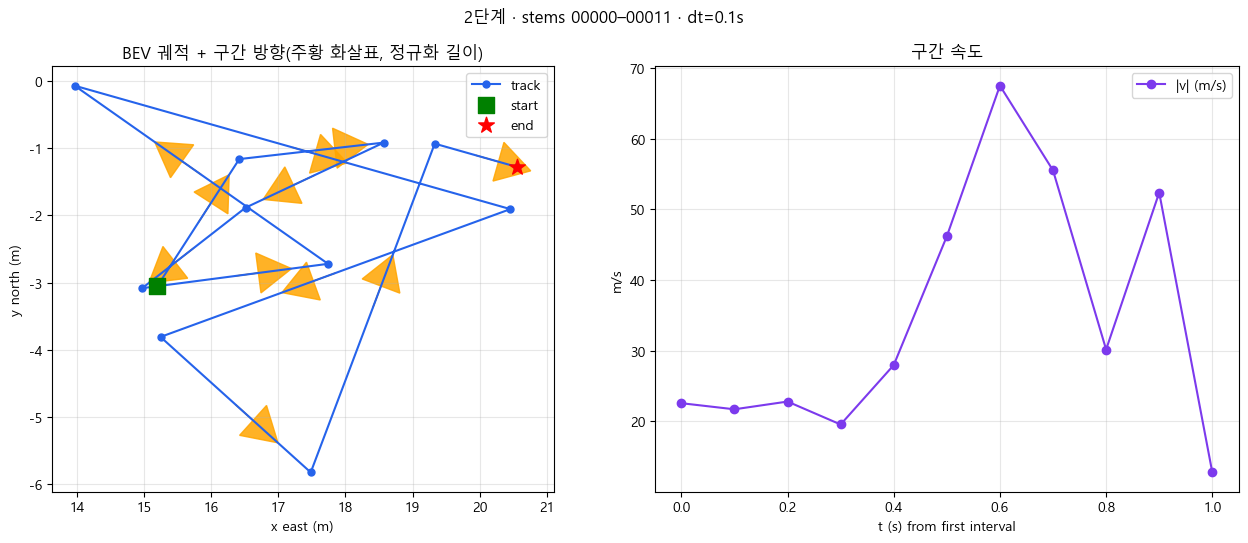

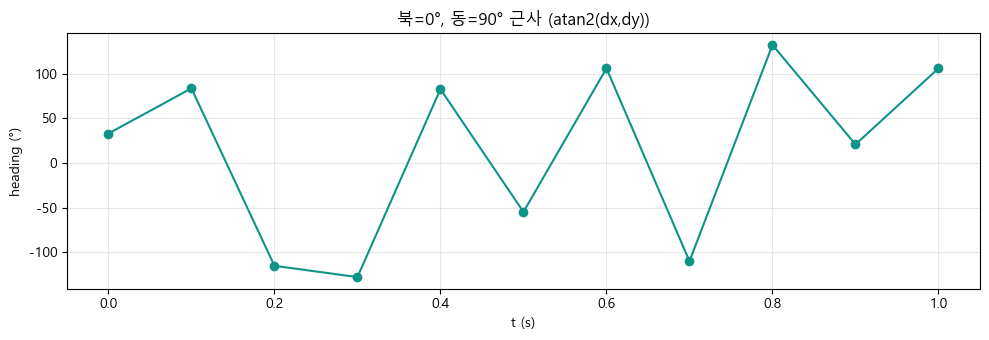

In [12]:
# BEV 궤적 + 구간 화살표
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.plot(traj[:, 0], traj[:, 1], "o-", color="#2563eb", linewidth=1.5, markersize=5, label="track")
ax.scatter(traj[0, 0], traj[0, 1], s=140, c="green", marker="s", zorder=6, label="start")
ax.scatter(traj[-1, 0], traj[-1, 1], s=140, c="red", marker="*", zorder=6, label="end")

scale = 0.35
for i in range(len(dxyz)):
    mx = 0.5 * (traj[i, 0] + traj[i + 1, 0])
    my = 0.5 * (traj[i, 1] + traj[i + 1, 1])
    dx, dy = dxyz[i, 0], dxyz[i, 1]
    n = max(np.hypot(dx, dy), 1e-6)
    ax.arrow(mx, my, scale * dx / n, scale * dy / n, head_width=0.6, head_length=0.5, fc="orange", ec="orange", alpha=0.85)

ax.set_xlabel("x east (m)")
ax.set_ylabel("y north (m)")
ax.set_title("BEV 궤적 + 구간 방향(주황 화살표, 정규화 길이)")
ax.set_aspect("equal")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

ax2 = axes[1]
t_axis = np.arange(len(speed_mps)) * STAGE2_DT_SEC
ax2.plot(t_axis, speed_mps, "o-", color="#7c3aed", label="|v| (m/s)")
ax2.set_xlabel("t (s) from first interval")
ax2.set_ylabel("m/s")
ax2.set_title("구간 속도")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle(f"2단계 · stems {use_stems[0]}–{use_stems[-1]} · dt={STAGE2_DT_SEC}s")
plt.tight_layout()
plt.show()

fig2, ax3 = plt.subplots(figsize=(10, 3.5))
ax3.plot(t_axis, headings_deg, "o-", color="#0d9488")
ax3.set_xlabel("t (s)")
ax3.set_ylabel("heading (°)")
ax3.set_title("북=0°, 동=90° 근사 (atan2(dx,dy))")
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 다음(3단계) — 위험지역 예측

- **입력:** 여기서 얻은 `traj`, `speed_mps`, `headings_deg` + (선택) 지도·아군 위치.
- **베이스라인:** 일정 시간 **등속 외삽**으로 도달 가능 영역(부채꼴/타원) 후 **격자 위험도**.
- **학습:** 위험 라벨(규칙 생성 weak label) 후 BEV 맵 회귀.

## 환경 변수 요약

| 변수 | 기본 | 의미 |
|------|------|------|
| `STAGE2_NUM_FRAMES` | 12 | 연속 로드 프레임 수 |
| `STAGE2_DT_SEC` | 0.1 | 프레임 간격(초), 속도 스케일 |
| `STAGE2_START_INDEX` | 0 | `stems` 배열 시작 인덱스 |
| `STAGE2_MAX_ASSOC_M` | 50 | 큰 점프 시 경고(연관은 유지) |
| `VOD_RADAR_DBSCAN_*` | 4 / 3 | 1단계와 동일 |